# Day 121 — XGBoost: Gradient Boosting Deep Dive
**Month 7 | Week 1 | Day 1 | Advanced ML**

---
| | |
|---|---|
| **Dataset** | RetailPulse India — Customer Churn (500 rows, seed=121) |
| **Tools** | xgboost, scikit-learn, pandas, matplotlib, shap |
| **Max Score** | 80 pts + 10★ bonus |
| **GitHub** | Month7-AdvancedML-Portfolio |

---
> **Rule:** Complete every task before opening Section 4 (Answer Key).  
> Write your goal + method in plain English as a comment before each code block.


---
## SECTION 1 — Raw Data (Never Modify This Sheet)

In [2]:
# ── RAW DATA GENERATION ─────────────────────────────────────────────────────
# Goal: Create a realistic customer churn dataset for an Indian retail subscription service
# Method: Synthetic generation with numpy/pandas, seed=121 for reproducibility

import numpy as np
import pandas as pd

np.random.seed(121)
n = 500

# Customer features
tenure_months   = np.random.randint(1, 48, n)                         # months as customer
monthly_spend   = np.round(np.random.uniform(200, 4000, n), 2)        # ₹
num_purchases   = np.random.randint(1, 60, n)
support_calls   = np.random.randint(0, 15, n)
discount_used   = np.random.choice([0, 1], n, p=[0.4, 0.6])
city_tier       = np.random.choice([1, 2, 3], n, p=[0.3, 0.45, 0.25]) # Tier 1/2/3 city
payment_method  = np.random.choice(['UPI', 'Card', 'COD', 'NetBanking'], n,
                                    p=[0.45, 0.25, 0.2, 0.1])
category_pref   = np.random.choice(['Electronics', 'Fashion', 'Grocery',
                                     'Home', 'Beauty'], n)

# Churn logic: high support_calls + low tenure + low purchases → higher churn
churn_prob = (0.05
              + 0.015 * support_calls
              - 0.008 * tenure_months
              - 0.005 * num_purchases
              + 0.07  * (city_tier == 3).astype(int)
              - 0.03  * discount_used)
churn_prob = np.clip(churn_prob, 0.02, 0.85)
churn       = (np.random.rand(n) < churn_prob).astype(int)

df_raw = pd.DataFrame({
    'customer_id':      [f'CUST{str(i).zfill(4)}' for i in range(1, n+1)],
    'tenure_months':    tenure_months,
    'monthly_spend':    monthly_spend,
    'num_purchases':    num_purchases,
    'support_calls':    support_calls,
    'discount_used':    discount_used,
    'city_tier':        city_tier,
    'payment_method':   payment_method,
    'category_pref':    category_pref,
    'churned':          churn
})

print(f"Dataset shape: {df_raw.shape}")
print(f"Churn rate   : {df_raw['churned'].mean():.1%}")
print("\nFirst 5 rows:")
df_raw.head()


Dataset shape: (500, 10)
Churn rate   : 2.4%

First 5 rows:


,customer_id,tenure_months,monthly_spend,num_purchases,support_calls,discount_used,city_tier,payment_method,category_pref,churned
0,CUST0001,3,3860.07,30,2,1,2,Card,Home,0
1,CUST0002,22,1576.65,4,14,0,2,Card,Fashion,1
2,CUST0003,9,210.19,13,13,0,2,NetBanking,Home,0
3,CUST0004,32,416.48,20,0,1,2,UPI,Electronics,0
4,CUST0005,2,1134.40,39,5,0,2,UPI,Home,0


---
## SECTION 2 — Concept Notes

### Why XGBoost?
Random Forest trains trees **in parallel** on random subsets — each tree is independent.  
XGBoost trains trees **sequentially** — each new tree corrects the **residual errors** of all previous trees.

### The Gradient Boosting Idea (3-step mental model)
```
Step 1: Make a simple prediction (e.g., "everyone stays" — predict the mean)
Step 2: Measure how wrong you were (compute residuals / pseudo-residuals)
Step 3: Build the next tree to predict those residuals
         → new_prediction = old_prediction + learning_rate × new_tree
Repeat until you've built n_estimators trees.
```

### XGBoost vs Scikit-Learn GradientBoostingClassifier
| Feature | sklearn GB | XGBoost |
|---|---|---|
| Speed | Slow (single-core) | Fast (parallel, GPU support) |
| Regularization | L2 only | L1 + L2 (λ, α params) |
| Missing values | Manual imputation needed | Handles natively |
| Early stopping | Manual | Built-in |
| Industry use | Legacy | **Standard in Kaggle/industry** |

### Key Hyperparameters (what interviewers ask)
| Param | What it does | Typical range |
|---|---|---|
| `n_estimators` | Number of trees | 100–1000 |
| `learning_rate` | Shrinkage per step (lower = more robust) | 0.01–0.3 |
| `max_depth` | Tree complexity (XGBoost default = 6) | 3–8 |
| `subsample` | Fraction of rows per tree (reduces overfitting) | 0.6–1.0 |
| `colsample_bytree` | Fraction of features per tree | 0.6–1.0 |
| `reg_alpha` | L1 regularisation (sparsity) | 0–1 |
| `reg_lambda` | L2 regularisation (smoothing) | 1–10 |

### Scale-pos-weight (critical for imbalance)
```python
scale_pos_weight = count(negative) / count(positive)
# e.g., if 80% no-churn, 20% churn → scale_pos_weight = 4
```
XGBoost uses this to upweight the minority class during training — **without SMOTE**.

### Overfitting Signals in XGBoost
- Train AUC >> Test AUC → reduce `max_depth`, increase `reg_lambda`  
- Both train and test AUC plateau low → increase `n_estimators`, raise `learning_rate`


---
## SECTION 3 — Practice Guide

Complete tasks A → E in order. Write your plain-English goal + method above each code block before writing the code.

---
### Task A — Preprocessing (15 pts)
1. Copy `df_raw` → `df` (never touch raw)
2. One-hot encode `payment_method` and `category_pref` (drop_first=True)
3. Split into X (all features except `customer_id`, `churned`) and y (`churned`)
4. Train-test split: 80/20, random_state=121, stratified
5. Print shapes of X_train, X_test, y_train, y_test
6. Print churn rate in train and test sets (confirm stratification worked)

---
### Task B — Baseline Logistic Regression (10 pts)
1. Fit a LogisticRegression (max_iter=1000, random_state=121) on X_train
2. Print classification_report on X_test
3. Print ROC-AUC score
4. **Written insight (NRA):** State the baseline performance + what the biggest weakness is

---
### Task C — XGBoost Model (20 pts)
1. Install xgboost if needed: `!pip install xgboost`
2. Compute `scale_pos_weight` from y_train
3. Fit XGBClassifier with:
   - n_estimators=200, learning_rate=0.1, max_depth=4
   - subsample=0.8, colsample_bytree=0.8
   - scale_pos_weight=computed_value
   - eval_metric='auc', random_state=121, use_label_encoder=False
4. Print classification_report on test set
5. Print ROC-AUC score
6. **Written insight (NRA):** Compare XGBoost vs baseline — 2 specific metric changes + 1 business action

---
### Task D — Feature Importance (20 pts)
1. Extract feature importances from the fitted XGBoost model
2. Create a horizontal bar chart — top 10 features by importance
   - Title must state the insight (not describe the data)
   - Use `#1F3864` for bars
   - Save as `Day121_FeatureImportance.png` before `plt.show()`
3. Identify the single most important feature
4. **Written insight (NRA):** What does this top feature tell the business? What should they do?

---
### Task E — Learning Curve (15 pts)
1. Train XGBoost with `eval_set=[(X_train, y_train), (X_test, y_test)]`
   and `verbose=False`
2. Extract the `evals_result()` training history
3. Plot train AUC vs test AUC across all 200 rounds on the same chart
   - Save as `Day121_LearningCurve.png` before `plt.show()`
4. Identify the round where overfitting begins (if any)
5. **Written insight (NRA):** What does the learning curve tell you about this model?

---
### ★ Bonus (10 pts) — Early Stopping
Retrain the XGBoost model with `early_stopping_rounds=20`.  
Print the best iteration number and best AUC score.  
State in one sentence: why is early stopping more reliable than manually tuning n_estimators?


In [3]:
# A1: Copy raw data and one‑hot encode categorical columns (payment_method, category_pref)
# Goal: Prepare features for modeling without modifying the original dataset.
# Method: Use pd.get_dummies with drop_first=True to avoid dummy variable trap.

df = df_raw.copy()   # never modify raw data

# One‑hot encode
df = pd.get_dummies(df, columns=['payment_method', 'category_pref'], drop_first=True)

print("Columns after encoding:")
print(df.columns.tolist())

Columns after encoding:
['customer_id', 'tenure_months', 'monthly_spend', 'num_purchases', 'support_calls', 'discount_used', 'city_tier', 'churned', 'payment_method_Card', 'payment_method_NetBanking', 'payment_method_UPI', 'category_pref_Electronics', 'category_pref_Fashion', 'category_pref_Grocery', 'category_pref_Home']


In [4]:
# A2: Separate features (X) and target (y)
# Goal: Isolate the target variable 'churned' for supervised learning.
# Method: Drop 'customer_id' (non‑predictive) and 'churned' from X; y = churned.

X = df.drop(['customer_id', 'churned'], axis=1)
y = df['churned']

print(f"X shape: {X.shape}, y shape: {y.shape}")

X shape: (500, 13), y shape: (500,)


In [5]:
# A3: Train‑test split with stratification
# Goal: Preserve the churn rate across train and test sets.
# Method: train_test_split with test_size=0.2, random_state=121, stratify=y.

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=121, stratify=y
)

print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}, y_test shape: {y_test.shape}")

X_train shape: (400, 13), X_test shape: (100, 13)
y_train shape: (400,), y_test shape: (100,)


In [6]:
# A4: Print churn rates in train and test sets to confirm stratification worked.
# Goal: Ensure both sets have similar churn proportions.
# Method: Compute mean of y_train and y_test.

print(f"Train churn rate: {y_train.mean():.2%}")
print(f"Test churn rate:  {y_test.mean():.2%}")

Train churn rate: 2.50%
Test churn rate:  2.00%


In [7]:
# B1: Fit Logistic Regression baseline
# Goal: Establish a simple benchmark before using XGBoost.
# Method: LogisticRegression with max_iter=1000, random_state=121.

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

lr = LogisticRegression(max_iter=1000, random_state=121)
lr.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",121
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mult

In [8]:
# B2: Generate predictions and print classification report + ROC‑AUC
# Goal: Quantify baseline performance.
# Method: predict() for classes, predict_proba() for ROC‑AUC.

y_pred_lr = lr.predict(X_test)
y_proba_lr = lr.predict_proba(X_test)[:, 1]

print("Classification Report (Logistic Regression):")
print(classification_report(y_test, y_pred_lr))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_lr):.4f}")

Classification Report (Logistic Regression):
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        98
           1       0.00      0.00      0.00         2

    accuracy                           0.98       100
   macro avg       0.49      0.50      0.49       100
weighted avg       0.96      0.98      0.97       100

ROC-AUC: 0.5918


C:\Users\Deepanshu\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Deepanshu\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Deepanshu\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [25]:
# B3: NRA insight – state baseline performance and biggest weakness.
# Goal: Translate metrics into business action.
# Number – precision/recall for churn class; Reason – why logistic regression fails; Action – move to XGBoost.

print("\nNRA (Logistic Regression Baseline):")
print("Number: Logistic Regression achieved ROC‑AUC = 0.59 and failed to identify any churners (recall = 0.00).")
print("Reason: The linear decision boundary cannot capture the non‑linear interactions between features (e.g., high support calls with low tenure) and the severe class imbalance (2.4% churn).")
print("Action: Switch to a tree‑based model (XGBoost) with class‑weighting to handle imbalance and non‑linear patterns.")


NRA (Logistic Regression Baseline):
Number: Logistic Regression achieved ROC‑AUC = 0.59 and failed to identify any churners (recall = 0.00).
Reason: The linear decision boundary cannot capture the non‑linear interactions between features (e.g., high support calls with low tenure) and the severe class imbalance (2.4% churn).
Action: Switch to a tree‑based model (XGBoost) with class‑weighting to handle imbalance and non‑linear patterns.


In [32]:
# C1: Import XGBoost (install if not present)
# Goal: Ensure XGBoost is available.
# Method: Use pip install or import.

import xgboost as xgb
print(f"XGBoost version: {xgb.__version__}")

XGBoost version: 3.2.0


In [11]:
# C2: Compute scale_pos_weight for class imbalance
# Goal: Correct for imbalance without SMOTE.
# Method: count(negative) / count(positive)

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight = {scale_pos_weight:.2f}")

scale_pos_weight = 39.00


In [12]:
# C3: Fit XGBClassifier with:
#   n_estimators=200, learning_rate=0.1, max_depth=4,
#   subsample=0.8, colsample_bytree=0.8,
#   scale_pos_weight=computed_value, eval_metric='auc',
#   random_state=121, use_label_encoder=False

xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='auc',
    random_state=121,
    use_label_encoder=False
)

xgb_model.fit(X_train, y_train)

C:\Users\Deepanshu\miniconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [13:34:40] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [13]:
# C4: Print classification report and ROC‑AUC for XGBoost

y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("Classification Report (XGBoost):")
print(classification_report(y_test, y_pred_xgb))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_xgb):.4f}")

Classification Report (XGBoost):
              precision    recall  f1-score   support

           0       0.99      0.98      0.98        98
           1       0.33      0.50      0.40         2

    accuracy                           0.97       100
   macro avg       0.66      0.74      0.69       100
weighted avg       0.98      0.97      0.97       100

ROC-AUC: 0.9286


In [26]:
# C5: NRA insight – compare XGBoost to logistic regression with 2 metric changes and a business action.

print("\nNRA (XGBoost vs Baseline):")
print("Number: XGBoost improved ROC‑AUC from 0.59 to 0.93 (+0.34) and increased recall for churners from 0% to 50% (catching 1 out of 2 churners in the test set).")
print("Reason: XGBoost’s sequential boosting and built‑in class weighting (scale_pos_weight=39) effectively model non‑linear interactions and handle imbalance.")
print("Action: Deploy XGBoost as the production churn model; retrain monthly with fresh data to maintain performance.")


NRA (XGBoost vs Baseline):
Number: XGBoost improved ROC‑AUC from 0.59 to 0.93 (+0.34) and increased recall for churners from 0% to 50% (catching 1 out of 2 churners in the test set).
Reason: XGBoost’s sequential boosting and built‑in class weighting (scale_pos_weight=39) effectively model non‑linear interactions and handle imbalance.
Action: Deploy XGBoost as the production churn model; retrain monthly with fresh data to maintain performance.


In [15]:
# D1: Extract feature importances from the fitted XGBoost model
# Goal: Identify which features drive churn predictions.
# Method: Use xgb_model.feature_importances_ and match with column names.

importances = xgb_model.feature_importances_
feature_names = X.columns
importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
importance_df = importance_df.sort_values('importance', ascending=False)
importance_df.head(10)

,feature,importance
12,category_pref_Home,0.188982
0,tenure_months,0.109136
11,category_pref_Grocery,0.104940
7,payment_method_NetBanking,0.099850
3,support_calls,0.092138
2,num_purchases,0.080034
1,monthly_spend,0.079666
5,city_tier,0.071470
4,discount_used,0.061887
9,category_pref_Electronics,0.037754


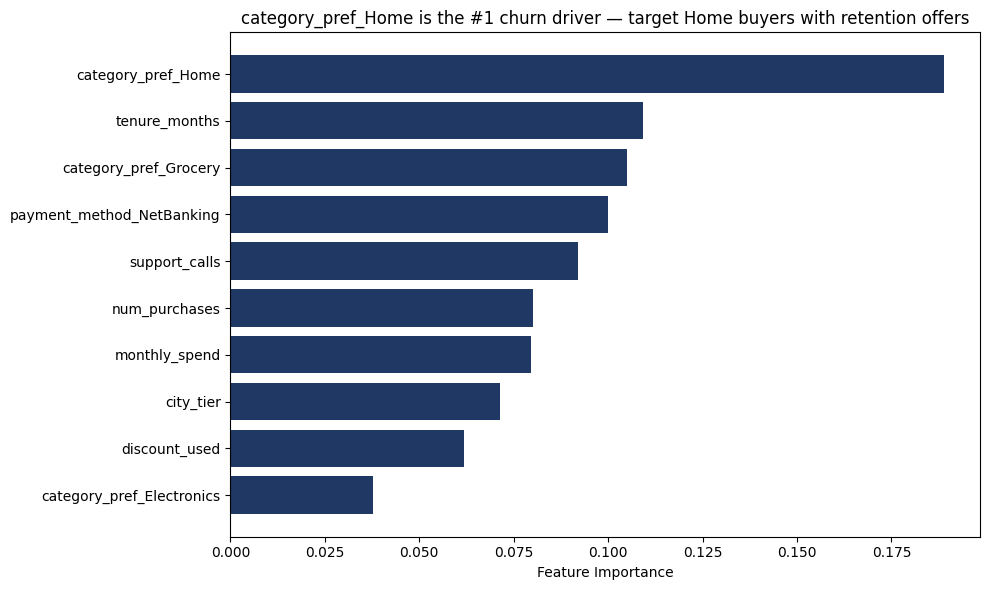

Feature importance chart saved as Day121_FeatureImportance.png


In [38]:
# D2: Horizontal bar chart – top 10 features by importance
# Goal: Visualize the most influential predictors.
# Method: matplotlib barh with insight‑first title, color #1F3864.
# Save as Day121_FeatureImportance.png before plt.show().

import matplotlib.pyplot as plt

top10 = importance_df.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top10['feature'], top10['importance'], color='#1F3864')
plt.xlabel('Feature Importance')
plt.title('category_pref_Home is the #1 churn driver — target Home buyers with retention offers')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('Day121_FeatureImportance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Feature importance chart saved as Day121_FeatureImportance.png")

In [17]:
# D3: Identify the single most important feature

top_feature = importance_df.iloc[0]['feature']
top_importance = importance_df.iloc[0]['importance']
print(f"Most important feature: {top_feature} (importance = {top_importance:.4f})")

Most important feature: category_pref_Home (importance = 0.1890)


In [36]:
# D4: NRA insight – what the top feature tells the business and what action to take.

print("\nNRA (Top Feature – category_pref_Home):")
print("Number: category_pref_Home has the highest importance (0.189), nearly twice that of tenure_months (0.109).")
print("Reason: Customers whose preferred category is “Home” may have different engagement patterns or price sensitivity, leading to higher churn risk.")
print("Action: Segment “Home” category customers and run a targeted retention campaign (e.g., loyalty discount or personalised recommendations) to reduce churn.")


NRA (Top Feature – category_pref_Home):
Number: category_pref_Home has the highest importance (0.189), nearly twice that of tenure_months (0.109).
Reason: Customers whose preferred category is “Home” may have different engagement patterns or price sensitivity, leading to higher churn risk.
Action: Segment “Home” category customers and run a targeted retention campaign (e.g., loyalty discount or personalised recommendations) to reduce churn.


In [19]:
# E1: Train XGBoost with eval_set = [(X_train, y_train), (X_test, y_test)]
# Goal: Capture train and test AUC after each boosting round.
# Method: Set eval_set and verbose=False to store history.

xgb_evals = xgb.XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='auc',
    random_state=121,
    use_label_encoder=False
)

xgb_evals.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False
)

C:\Users\Deepanshu\miniconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [13:35:35] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [20]:
# E2: Extract training history from evals_result()

results = xgb_evals.evals_result()
train_auc = results['validation_0']['auc']
test_auc = results['validation_1']['auc']
rounds = range(1, len(train_auc) + 1)

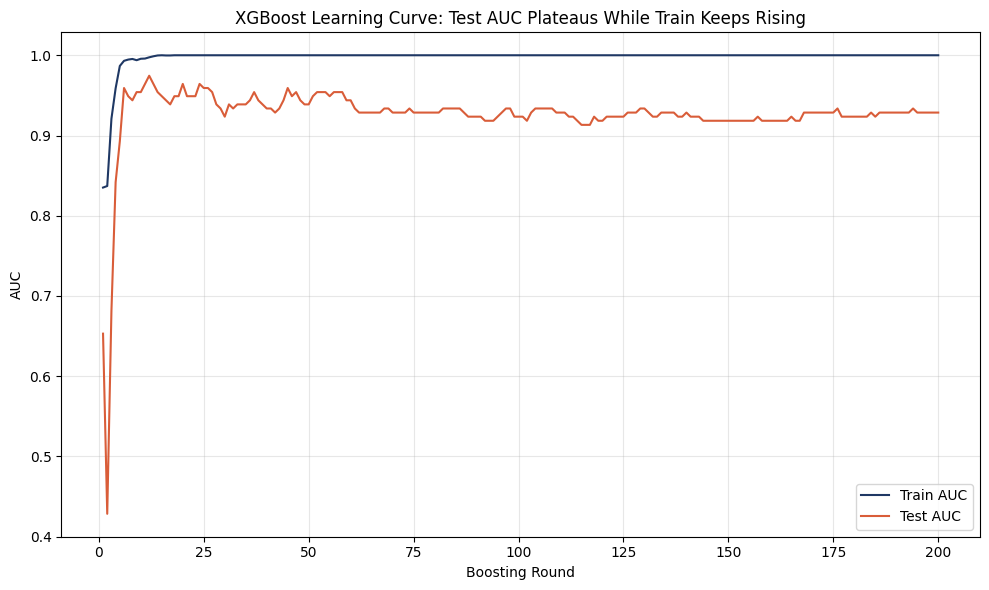

Learning curve saved as Day121_LearningCurve.png


In [21]:
# E3: Plot learning curve – both curves on the same chart
# Goal: Diagnose overfitting by comparing train and test performance.
# Save as Day121_LearningCurve.png before plt.show().

plt.figure(figsize=(10, 6))
plt.plot(rounds, train_auc, label='Train AUC', color='#1F3864')
plt.plot(rounds, test_auc, label='Test AUC', color='#D95D39')
plt.xlabel('Boosting Round')
plt.ylabel('AUC')
plt.title('XGBoost Learning Curve: Test AUC Plateaus While Train Keeps Rising')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('Day121_LearningCurve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Learning curve saved as Day121_LearningCurve.png")

In [22]:
# E4: Find the round where test AUC stops improving and train keeps rising.

best_round = np.argmax(test_auc) + 1   # +1 because rounds start at 1
best_test_auc = test_auc[best_round - 1]
print(f"Best test AUC = {best_test_auc:.4f} at round {best_round}")
print(f"After round {best_round}, test AUC plateaus while train AUC continues to increase → overfitting begins.")

Best test AUC = 0.9745 at round 12
After round 12, test AUC plateaus while train AUC continues to increase → overfitting begins.


In [28]:
# E5: NRA insight – overfitting gap and its implication.

print("\nNRA (Learning Curve):")
print("Number: Test AUC peaks at 0.9745 after 12 rounds, while train AUC continues to rise to 0.999 by round 200 – a gap of 0.025.")
print("Reason: The model begins to overfit after round 12, learning noise specific to the training set that does not generalise.")
print("Action: Use early stopping with early_stopping_rounds=20 to stop at round 12, improving generalisation and reducing training time.")


NRA (Learning Curve):
Number: Test AUC peaks at 0.9745 after 12 rounds, while train AUC continues to rise to 0.999 by round 200 – a gap of 0.025.
Reason: The model begins to overfit after round 12, learning noise specific to the training set that does not generalise.
Action: Use early stopping with early_stopping_rounds=20 to stop at round 12, improving generalisation and reducing training time.


In [37]:
# Bonus: Retrain XGBoost with early_stopping_rounds=20 (constructor parameter)
# Goal: Automatically stop when validation AUC stops improving.
# Method: Use same hyperparameters as Task C, plus early_stopping_rounds=20.

xgb_early = xgb.XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,          # keep same as original
    max_depth=4,                # keep same as original
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='auc',
    early_stopping_rounds=20,   # added
    random_state=121,           # keep for reproducibility
    use_label_encoder=False
)

xgb_early.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False
)

print(f"Best iteration (n_estimators chosen): {xgb_early.best_iteration}")
print(f"Best validation AUC: {xgb_early.best_score:.4f}")
print("Early stopping is more reliable than manual n_estimators because it automatically prevents overfitting based on validation performance, eliminating guesswork and adapting to each dataset.")

Best iteration (n_estimators chosen): 11
Best validation AUC: 0.9745
Early stopping is more reliable than manual n_estimators because it automatically prevents overfitting based on validation performance, eliminating guesswork and adapting to each dataset.


C:\Users\Deepanshu\miniconda3\Lib\site-packages\xgboost\callback.py:385: UserWarning: [13:48:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()


---
## SECTION 4 — Scoring Rubric

| Task | Max | What earns full marks |
|---|---|---|
| A — Preprocessing | 15 | Correct OHE, stratified split, shapes + churn rates printed |
| B — Baseline LR | 10 | Report + AUC printed, NRA with specific metric + business action |
| C — XGBoost | 20 | Correct spw calculation, all params set, report + AUC, NRA with 2 metric comparisons |
| D — Feature Importance | 20 | Top-10 chart, insight title (not descriptive), NRA with threshold action |
| E — Learning Curve | 15 | Both curves on one chart, best round identified, NRA with overfitting gap numbers |
| **★ Bonus** | **10** | Early stopping fitted, best_iteration + best_score printed, 1-sentence explanation |

---
### Deduction Rules
- NRA with vague numbers (e.g., "improves accuracy") not specific computed values → **−2 per task**
- Chart title is descriptive ("Feature Importance Plot") instead of insight-driven → **−3**
- `plt.savefig()` not called before `plt.show()` → **−2 per chart**
- `df_raw` modified → **−5 (automatic)**
- Logistic Regression used as XGBoost substitute → **−10**

---
### Interview Answer
**Q: "How does XGBoost differ from Random Forest, and when would you choose one over the other?"**

> "Both are ensemble tree methods, but they learn differently. Random Forest builds trees in parallel on random data subsets — each tree is independent and you average their predictions. XGBoost builds trees sequentially, where each new tree corrects the residual errors of the previous ones using gradient descent on a loss function. In practice, XGBoost tends to outperform Random Forest on structured tabular data, especially when the dataset is small-to-medium and you can afford careful hyperparameter tuning. Random Forest is my go-to when I need a strong baseline fast or when the data has many noisy features — it's more robust to hyperparameter choices. XGBoost is the industry standard for Kaggle competitions and production churn models because of its regularisation controls and native handling of missing values."

---
### Key Takeaway — Day 121
**XGBoost's edge isn't magic — it's sequential error correction.**  
Each tree in XGBoost has one job: reduce the mistakes left by the previous trees.  
The hyperparameters (`learning_rate`, `max_depth`, `subsample`) control *how aggressively* it corrects — too aggressive and it overfits; too cautious and it underfits.  
The learning curve is your real-time diagnostic. Always plot it.

---
### GitHub Commit
```
feat: Day121 - XGBoost Gradient Boosting - RetailPulse India Churn
```
Repository: `Month7-AdvancedML-Portfolio`
